# THỐNG KÊ DỮ LIỆU TAI NẠN GIAO THÔNG ĐƯỜNG BỘ TẠI ADDIS ABABA

## Chương 1. Giới thiệu

Số lượng tai nạn giao thông hiện nay đang được tính theo hàng năm trên các máy tính. Giúp giảm thời thống kê về thiệt hại về con người và tài sản của các nhân viên. Đồng thời để lại một khối dữ liệu đáng giá để phân tích và rút ra kinh nghiệm.

### 1.1. Phát biểu vấn đề

Trong báo cáo này nhóm chúng tôi muốn sử dụng phương pháp phân tích số liệu để trả lời các câu hỏi nghiên cứu liên quan đến độ tuổi tài tế, loại va chạm, mức độ va chạm,...

### 1.2. Giới thiệu bộ dữ liệu

Dữ liệu thu thập ở thu thập từ các sở cảnh sát quận thuộc thành phố Addis Ababa trong trong giai đoạn 2017-2020 ữ liệu có các thuộc tính như sau: (tham khảo các viết phần này ở đây: https://www.kaggle.com/datasets/saurabhshahane/road-traffic-accidents

### 1.3. Mục tiêu nghiên cứu đề tài

Xác định các yếu tố ảnh hưởng đến mức độ nghiêm trọng của tai nạn.

Phân tích dữ liệu để xây dựng mô hình dự đoán mức độ tai nạn.

### 1.4. Phạm vi nghiên cứu đề tài

Nghiên cứu dựa trên dữ liệu tai nạn giao thông từ bộ dữ liệu Kaggle với các thông tin về tài xế, điều kiện môi trường và kết quả tai nạn.

### 1.5. Ý nghĩa khoa học và thực tiễn

Giúp cơ quan quản lý hiểu rõ hơn các yếu tố gây tai nạn, đề xuất biện pháp an toàn.

Có thể ứng dụng trong các hệ thống cảnh báo sớm.

## Chương 2. Phân tích dữ liệu

### 2.1 Mô tả dữ liệu

In [1]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
#GitHup
!git clone https://github.com/QuocAnh1501/BaoCaoCuoiKy.git

Cloning into 'BaoCaoCuoiKy'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), 368.86 KiB | 3.02 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [3]:
import pandas as pd

df = pd.read_csv('/content/BaoCaoCuoiKy/RTA Dataset.csv')
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Đọc dữ liệu
df = pd.read_csv('/content/drive/MyDrive/BaoCaoCuoiKy/RTA Dataset.csv')
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
# Kiểm tra dữ liệu
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [5]:
# Làm sạch dữ liệu
df = df.dropna()

In [6]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [7]:
# Chia dữ liệu
from sklearn.model_selection import train_test_split

X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [9]:
# Đánh giá
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8719723183391004


### 2.2. Các câu hỏi nghiên cứu

Dựa vào thống kê bước đầu của dữ liệu, nhóm chúng tôi đặt ra các câu hỏi nghiên cứu như sau:
*   Q1. Nhóm tuổi tài xế nào gây ra nhiều vụ tai nạn nhất?
*   Q2. Giới tính tài xế nào gây ra nhiều tai nạn hơn?
*   Q3. Kinh nghiệm lái xe của tài xế phân bố như thế nào?
*   Q4. Thời tiết có ảnh hưởng đến số vụ tai nạn hay không?
*   Q5. Điều kiện ánh sáng ảnh hưởng thế nào đến tai nạn?
*   Q6. Loại phương tiện nào gây tai nạn nhiều nhất?
*   Q7. Tai nạn xảy ra nhiều nhất vào ngày nào trong tuần?
*   Q8. Tình trạng mặt đường ảnh hưởng thế nào đến tai nạn?
*   Q9. Khu vực nào xảy ra tai nạn nhiều nhất?
*   Q10. Mức độ nghiêm trọng của tai nạn phân bố ra sao?
*   Q11. Nhóm tuổi tài xế có ảnh hưởng đến mức độ tai nạn không?
*   Q12. Kinh nghiệm lái xe có ảnh hưởng đến mức độ tai nạn không?
*   Q13. Thời tiết có ảnh hưởng đến mức độ tai nạn không?
*   Q14. Điều kiện ánh sáng có ảnh hưởng đến mức độ tai nạn không?
*   Q15. Loại phương tiện có liên quan đến mức độ tai nạn không?











### 2.3. Phân tích dữ liệu để trả lời các câu hỏi nghiên cứu

In [10]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
8,308,0,0,1,4,0,3,5,3,0,...,2,2,1,4,2,0,2,0,1,2
9,308,0,0,1,4,0,0,0,3,1,...,10,1,1,0,2,0,2,5,9,1
12,327,4,0,1,4,0,0,11,3,1,...,2,3,2,5,3,0,2,5,10,2
13,327,4,1,1,4,0,2,5,3,3,...,12,3,2,5,3,2,2,5,12,2
14,327,4,1,1,4,0,3,0,3,0,...,2,0,0,0,2,0,2,5,10,1


In [11]:
df.describe()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,...,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000
mean,352.098304,2.941502,1.323988,0.960194,3.180685,0.312565,1.964001,5.572170,2.704742,2.878851,...,2.929041,1.462098,1.142610,2.618899,2.301488,0.928695,1.995154,4.822776,7.026999,1.842852
std,203.112452,2.033575,1.368010,0.260794,1.379219,0.719426,1.274382,4.465131,0.859029,1.846573,...,2.145056,1.328635,0.747397,2.124534,0.577271,1.347681,0.123337,0.917146,5.097386,0.392385
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188.000000,1.000000,0.000000,1.000000,2.000000,0.000000,1.000000,0.000000,3.000000,1.000000,...,2.000000,0.000000,1.000000,0.000000,2.000000,0.000000,2.000000,5.000000,1.000000,2.000000
50%,329.000000,3.000000,1.000000,1.000000,4.000000,0.000000,2.000000,5.000000,3.000000,3.000000,...,2.000000,1.000000,1.000000,3.000000,2.000000,0.000000,2.000000,5.000000,9.000000,2.000000
75%,505.000000,5.000000,2.000000,1.000000,4.000000,0.000000,3.000000,9.000000,3.000000,5.000000,...,3.000000,3.000000,2.000000,5.000000,3.000000,2.000000,2.000000,5.000000,11.000000,2.000000
max,741.000000,6.000000,4.000000,2.000000,6.000000,3.000000,6.000000,16.000000,3.000000,5.000000,...,12.000000,3.000000,2.000000,5.000000,3.000000,6.000000,3.000000,7.000000,19.000000,2.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2889 entries, 8 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         2889 non-null   int64
 1   Day_of_week                  2889 non-null   int64
 2   Age_band_of_driver           2889 non-null   int64
 3   Sex_of_driver                2889 non-null   int64
 4   Educational_level            2889 non-null   int64
 5   Vehicle_driver_relation      2889 non-null   int64
 6   Driving_experience           2889 non-null   int64
 7   Type_of_vehicle              2889 non-null   int64
 8   Owner_of_vehicle             2889 non-null   int64
 9   Service_year_of_vehicle      2889 non-null   int64
 10  Defect_of_vehicle            2889 non-null   int64
 11  Area_accident_occured        2889 non-null   int64
 12  Lanes_or_Medians             2889 non-null   int64
 13  Road_allignment              2889 non-null   int64
 

In [13]:
# ĐỔI NHÃN CHO CÁC BIẾN TRONG DATASET

# Nhóm tuổi tài xế
age_map = {
"18-30": "18-30 tuổi",
"31-50": "31-50 tuổi",
"Over 51": "Trên 51 tuổi",
"Under 18": "Dưới 18 tuổi",
"Unknown": "Không rõ"
}

df['Nhóm_tuổi_tài_xế'] = df['Age_band_of_driver'].map(age_map)
# Giới tính
gender_map = {
0: "Nữ",
1: "Nam",
2: "Không rõ"
}
df["Giới_tính"] = df["Sex_of_driver"].map(gender_map)

# Mức độ tai nạn
severity_map = {
0: "Tai nạn nhẹ",
1: "Tai nạn nghiêm trọng",
2: "Tử vong"
}

df['Mức_độ_tai_nạn'] = df['Accident_severity'].map(severity_map)


# Điều kiện ánh sáng
light_map = {
0: "Ban ngày",
1: "Ban đêm có đèn",
2: "Ban đêm không đèn",
3: "Ánh sáng yếu"
}

df['Điều_kiện_ánh_sáng'] = df['Light_conditions'].map(light_map)


# Điều kiện thời tiết
weather_map = {
0: "Trời nhiều mây",
1: "Sương mù",
2: "Thời tiết bình thường",
3: "Trời mưa"
}

df['Thời_tiết'] = df['Weather_conditions'].map(weather_map)
# Kinh nghiệm lái xe
experience_map = {
0: "Không có bằng lái",
1: "Dưới 1 năm",
2: "1-2 năm",
3: "2-5 năm",
4: "5-10 năm",
5: "Trên 10 năm"
}

df["Kinh_nghiệm_lái_xe"] = df["Driving_experience"].map(experience_map)
# Loại phương tiện
vehicle_map = {
0: "Ô tô",
1: "Xe tải",
2: "Xe buýt",
3: "Xe máy",
4: "Khác"
}

df["Loại_phương_tiện"] = df["Type_of_vehicle"].map(vehicle_map)
# Ngày trong tuần
day_map = {
0: "Thứ hai",
1: "Thứ ba",
2: "Thứ tư",
3: "Thứ năm",
4: "Thứ sáu",
5: "Thứ bảy",
6: "Chủ nhật"
}

df["Ngày_trong_tuần"] = df["Day_of_week"].map(day_map)
# Tình trạng mặt đường
road_surface_map = {
0: "Khô ráo",
1: "Ướt",
2: "Có bùn",
3: "Có tuyết",
4: "Khác"
}

df["Tình_trạng_mặt_đường"] = df["Road_surface_conditions"].map(road_surface_map)
# Khu vực tai nạn
area_map = {
0: "Khu dân cư",
1: "Khu thương mại",
2: "Khu công nghiệp",
3: "Vùng nông thôn",
4: "Khác"
}

df["Khu_vực_tai_nạn"] = df["Area_accident_occured"].map(area_map)

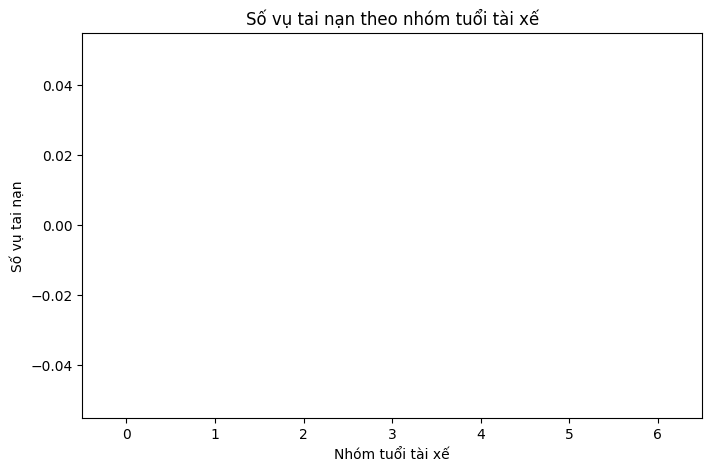

In [14]:
# Q1. Độ tuổi tài xế nào gây tai nạn nhiều nhất
plt.figure(figsize=(8,5))

sns.countplot(x='Nhóm_tuổi_tài_xế', data=df)

plt.title("Số vụ tai nạn theo nhóm tuổi tài xế")
plt.xlabel("Nhóm tuổi tài xế")
plt.ylabel("Số vụ tai nạn")

plt.show()

Biểu đồ cho thấy số vụ tai nạn tập trung nhiều ở nhóm tuổi trẻ. Điều này có thể do nhóm tuổi này tham gia giao thông thường xuyên hơn hoặc kinh nghiệm lái xe còn hạn chế.


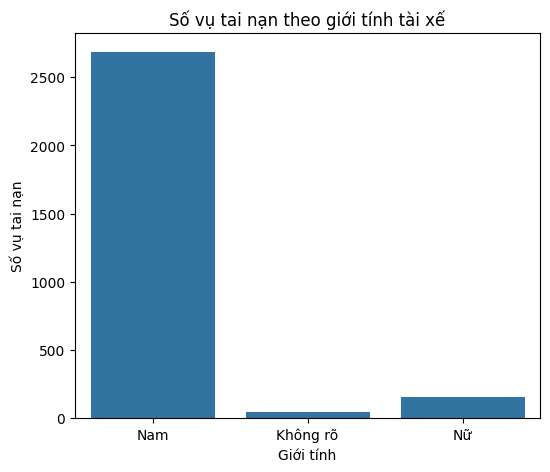

In [15]:
# Q2. Giới tính tài xế nào gây tai nạn nhiều hơn
plt.figure(figsize=(6,5))

sns.countplot(x="Giới_tính", data=df)

plt.title("Số vụ tai nạn theo giới tính tài xế")
plt.xlabel("Giới tính")
plt.ylabel("Số vụ tai nạn")

plt.show()

Kết quả cho thấy số vụ tai nạn của tài xế nam cao hơn so với tài xế nữ. Điều này có thể do tỷ lệ nam tham gia lái xe nhiều hơn trong thực tế.


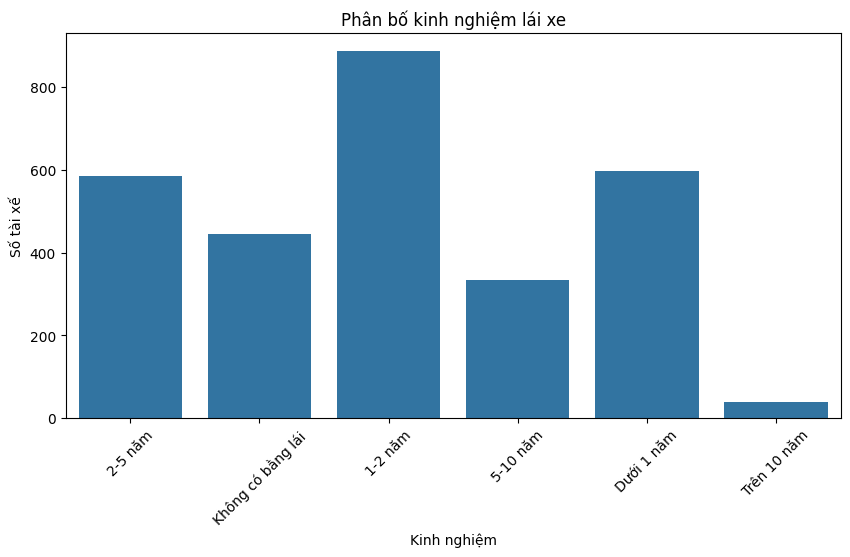

In [16]:
# Q3. Kinh nghiệm lái xe của tài xế phân bố như thế nào?
plt.figure(figsize=(10,5))

sns.countplot(x='Kinh_nghiệm_lái_xe', data=df)

plt.title("Phân bố kinh nghiệm lái xe")
plt.xlabel("Kinh nghiệm")
plt.ylabel("Số tài xế")

plt.xticks(rotation=45)

plt.show()

Biểu đồ cho thấy phần lớn tài xế có kinh nghiệm lái xe ở mức trung bình đến cao. Tuy nhiên vẫn có một số tài xế có kinh nghiệm thấp, điều này có thể làm tăng nguy cơ xảy ra tai nạn giao thông.

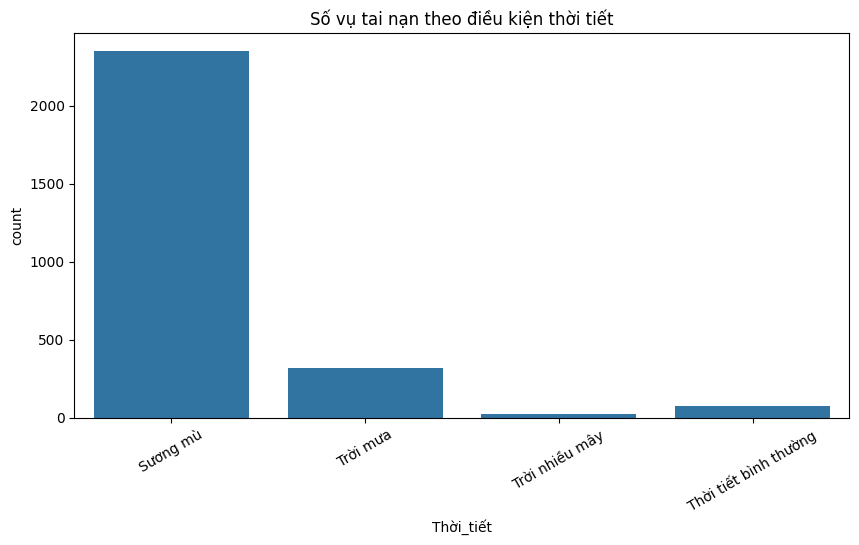

In [ ]:
# Q4. Thời tiết nào xảy ra nhiều tai nạn nhất
plt.figure(figsize=(10,5))
sns.countplot(x="Thời_tiết", data=df)
plt.title("Số vụ tai nạn theo điều kiện thời tiết")
plt.xticks(rotation=30)
plt.show()

Biểu đồ cho thấy tai nạn xảy ra trong nhiều điều kiện thời tiết khác nhau. Tuy nhiên, thời tiết xấu như mưa hoặc sương mù có thể làm giảm tầm nhìn và tăng nguy cơ tai nạn giao thông.

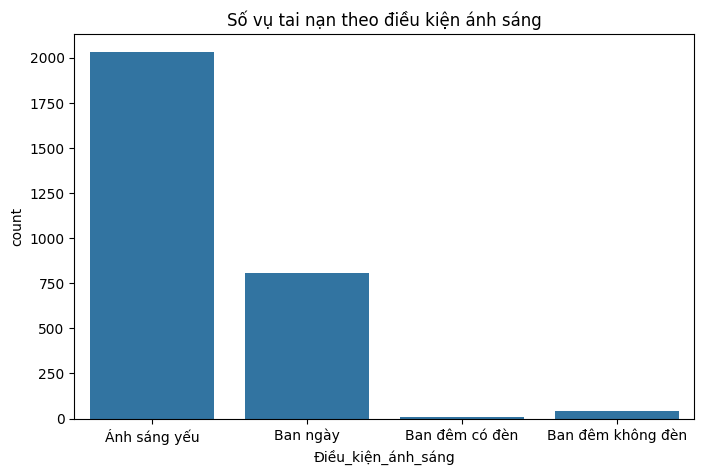

In [ ]:
# Q5. Điều kiện ánh sáng ảnh hưởng đến tai nạn như thế nào
plt.figure(figsize=(8,5))
sns.countplot(x="Điều_kiện_ánh_sáng", data=df)
plt.title("Số vụ tai nạn theo điều kiện ánh sáng")
plt.show()

Tai nạn giao thông thường xảy ra nhiều hơn trong điều kiện ánh sáng yếu hoặc ban đêm. Điều này có thể do tầm nhìn hạn chế khiến tài xế khó quan sát và phản ứng kịp thời.

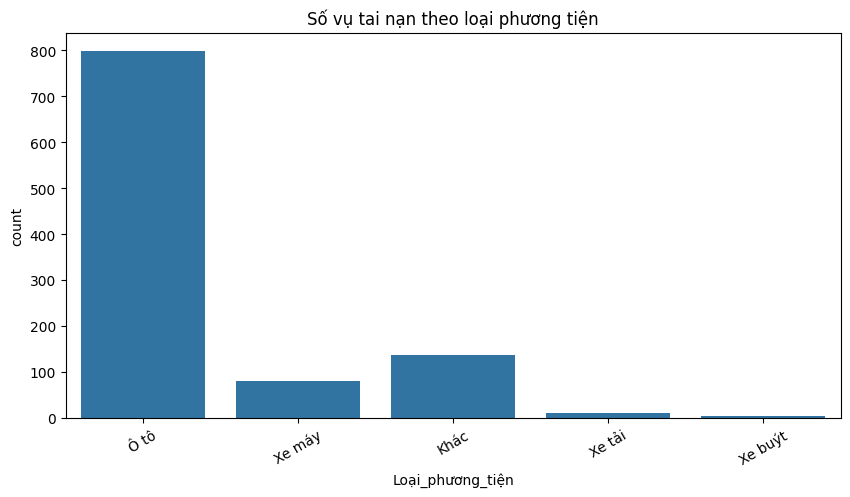

In [ ]:
# Q6. Loại phương tiện nào gây tai nạn nhiều nhất
plt.figure(figsize=(10,5))
sns.countplot(x="Loại_phương_tiện", data=df)
plt.title("Số vụ tai nạn theo loại phương tiện")
plt.xticks(rotation=30)
plt.show()

Biểu đồ cho thấy một số loại phương tiện chiếm tỷ lệ tai nạn cao hơn so với các loại khác. Điều này có thể liên quan đến số lượng phương tiện lưu thông hoặc đặc điểm vận hành của từng loại phương tiện.

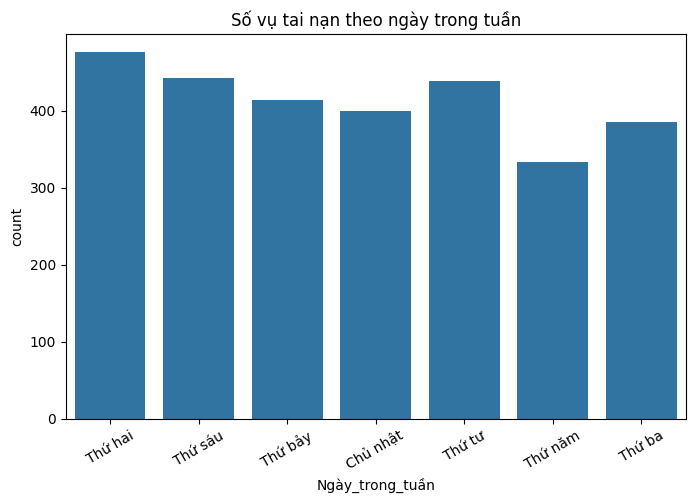

In [ ]:
# Q7. Tai nạn thường xảy ra nhiều nhất vào ngày nào trong tuần
plt.figure(figsize=(8,5))
sns.countplot(x="Ngày_trong_tuần", data=df)
plt.title("Số vụ tai nạn theo ngày trong tuần")
plt.xticks(rotation=30)
plt.show()

Tai nạn giao thông xảy ra trong tất cả các ngày trong tuần. Một số ngày có thể ghi nhận số vụ tai nạn cao hơn, có thể liên quan đến mật độ giao thông hoặc các hoạt động sinh hoạt trong ngày đó.

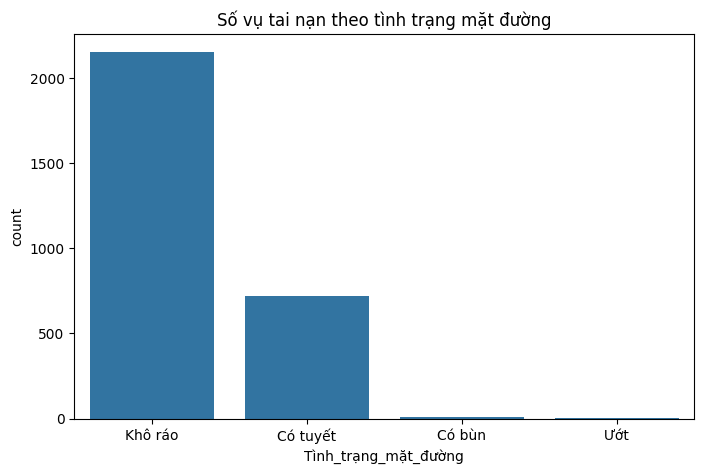

In [ ]:
# Q8. Tình trạng mặt đường ảnh hưởng thế nào đến tai nạn
plt.figure(figsize=(8,5))
sns.countplot(x="Tình_trạng_mặt_đường", data=df)
plt.title("Số vụ tai nạn theo tình trạng mặt đường")
plt.show()

Biểu đồ cho thấy tai nạn xảy ra trong nhiều điều kiện mặt đường khác nhau. Mặt đường trơn trượt hoặc ướt có thể làm giảm độ bám của bánh xe, từ đó làm tăng nguy cơ tai nạn.

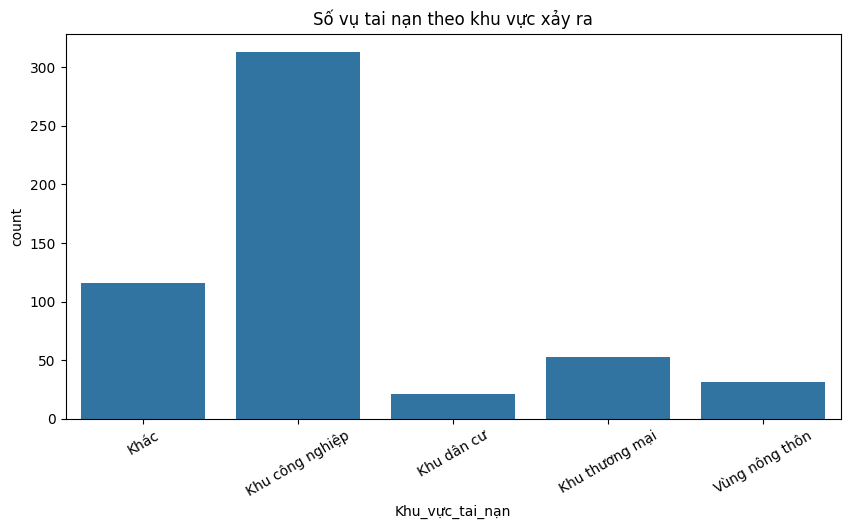

In [ ]:
# Q9.Khu vực tai nạn ảnh hưởng thế nào đến tai nạn
plt.figure(figsize=(10,5))
sns.countplot(x="Khu_vực_tai_nạn", data=df)
plt.title("Số vụ tai nạn theo khu vực xảy ra")
plt.xticks(rotation=30)
plt.show()

Tai nạn giao thông xảy ra ở nhiều khu vực khác nhau như khu dân cư, khu thương mại hoặc vùng nông thôn. Một số khu vực có thể có mật độ tai nạn cao hơn do lưu lượng phương tiện lớn.

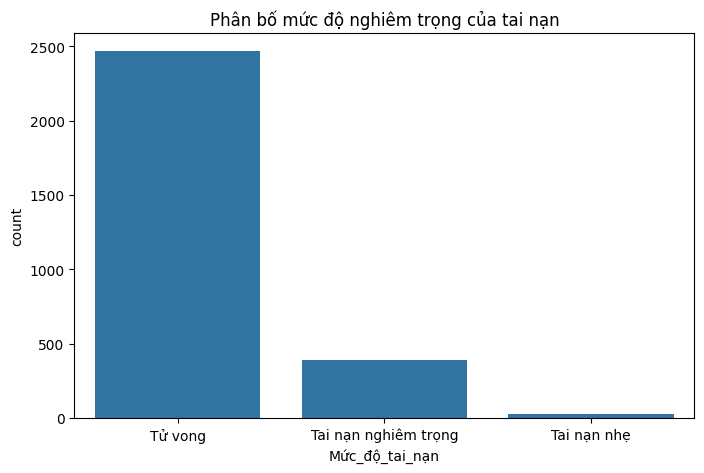

In [ ]:
# Q10. Mức độ nghiêm trọng của tai nạn phân bố ra sao
plt.figure(figsize=(8,5))
sns.countplot(x="Mức_độ_tai_nạn", data=df)
plt.title("Phân bố mức độ nghiêm trọng của tai nạn")
plt.show()

Biểu đồ cho thấy phần lớn các vụ tai nạn thuộc mức độ nhẹ. Tuy nhiên vẫn có một số vụ tai nạn nghiêm trọng hoặc gây tử vong, cho thấy tai nạn giao thông vẫn là vấn đề đáng quan tâm.

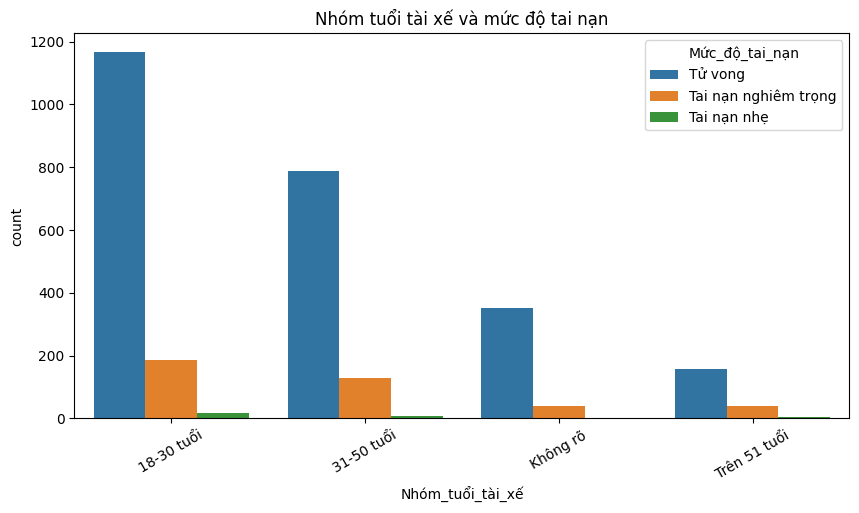

In [ ]:
# Q11. Nhóm tuổi tài xế có ảnh hưởng đến mức độ nghiêm trọng của tai nạn không
plt.figure(figsize=(10,5))
sns.countplot(x="Nhóm_tuổi_tài_xế", hue="Mức_độ_tai_nạn", data=df)
plt.title("Nhóm tuổi tài xế và mức độ tai nạn")
plt.xticks(rotation=30)
plt.show()

Biểu đồ cho thấy mức độ tai nạn khác nhau giữa các nhóm tuổi tài xế. Một số nhóm tuổi có thể liên quan đến các vụ tai nạn nghiêm trọng hơn

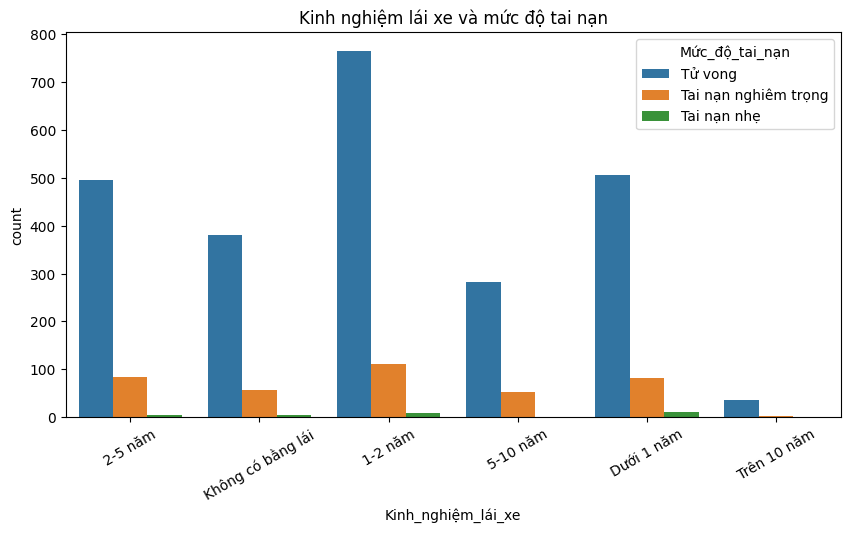

In [ ]:
# Q12. Kinh nghiệm lái xe có ảnh hưởng đến mức độ tai nạn không
plt.figure(figsize=(10,5))
sns.countplot(x="Kinh_nghiệm_lái_xe", hue="Mức_độ_tai_nạn", data=df)
plt.title("Kinh nghiệm lái xe và mức độ tai nạn")
plt.xticks(rotation=30)
plt.show()

Những tài xế có ít kinh nghiệm lái xe có thể dễ gặp tai nạn nghiêm trọng hơn do khả năng xử lý tình huống trên đường còn hạn chế.

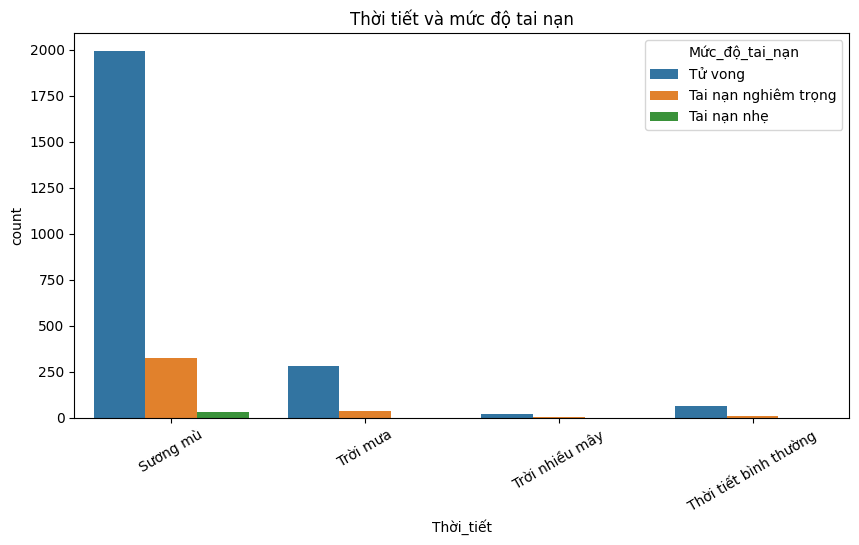

In [ ]:
# Q13. Thời tiết có ảnh hưởng đến mức độ nghiêm trọng của tai nạn không
plt.figure(figsize=(10,5))
sns.countplot(x="Thời_tiết", hue="Mức_độ_tai_nạn", data=df)
plt.title("Thời tiết và mức độ tai nạn")
plt.xticks(rotation=30)
plt.show()

Điều kiện thời tiết xấu như mưa hoặc sương mù có thể làm tăng mức độ nghiêm trọng của tai nạn do tầm nhìn giảm và đường trơn trượt.

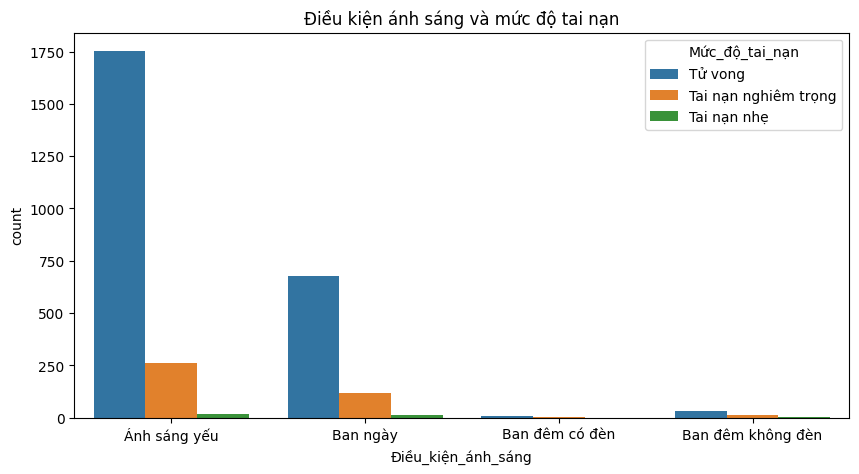

In [ ]:
# Q14. Điều kiện ánh sáng có làm tăng mức độ nghiêm trọng của tai nạn không
plt.figure(figsize=(10,5))
sns.countplot(x="Điều_kiện_ánh_sáng", hue="Mức_độ_tai_nạn", data=df)
plt.title("Điều kiện ánh sáng và mức độ tai nạn")
plt.show()

Các vụ tai nạn xảy ra vào ban đêm hoặc trong điều kiện ánh sáng yếu có xu hướng nghiêm trọng hơn do tầm nhìn bị hạn chế.

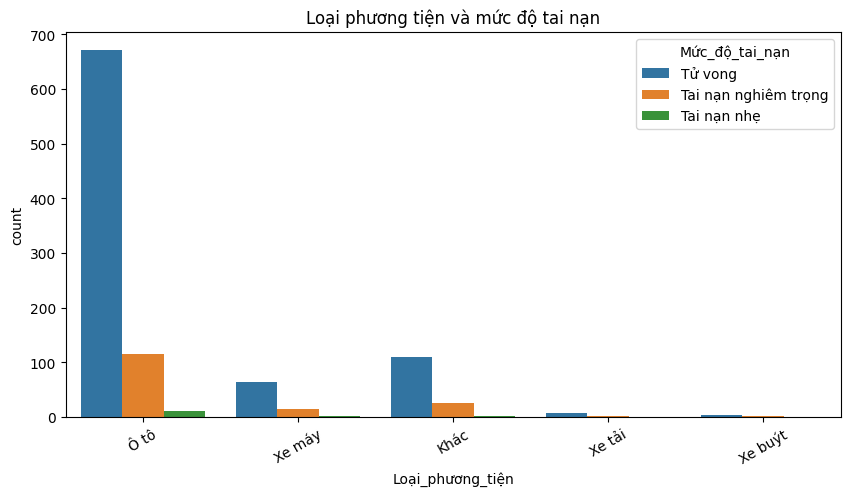

In [ ]:
# Q15. Loại phương tiện có liên quan đến mức độ tai nạn không
plt.figure(figsize=(10,5))
sns.countplot(x="Loại_phương_tiện", hue="Mức_độ_tai_nạn", data=df)
plt.title("Loại phương tiện và mức độ tai nạn")
plt.xticks(rotation=30)
plt.show()

Biểu đồ cho thấy mức độ tai nạn có sự khác biệt giữa các loại phương tiện. Một số loại phương tiện có thể liên quan đến các vụ tai nạn nghiêm trọng hơn do kích thước hoặc tốc độ di chuyển.

================================================

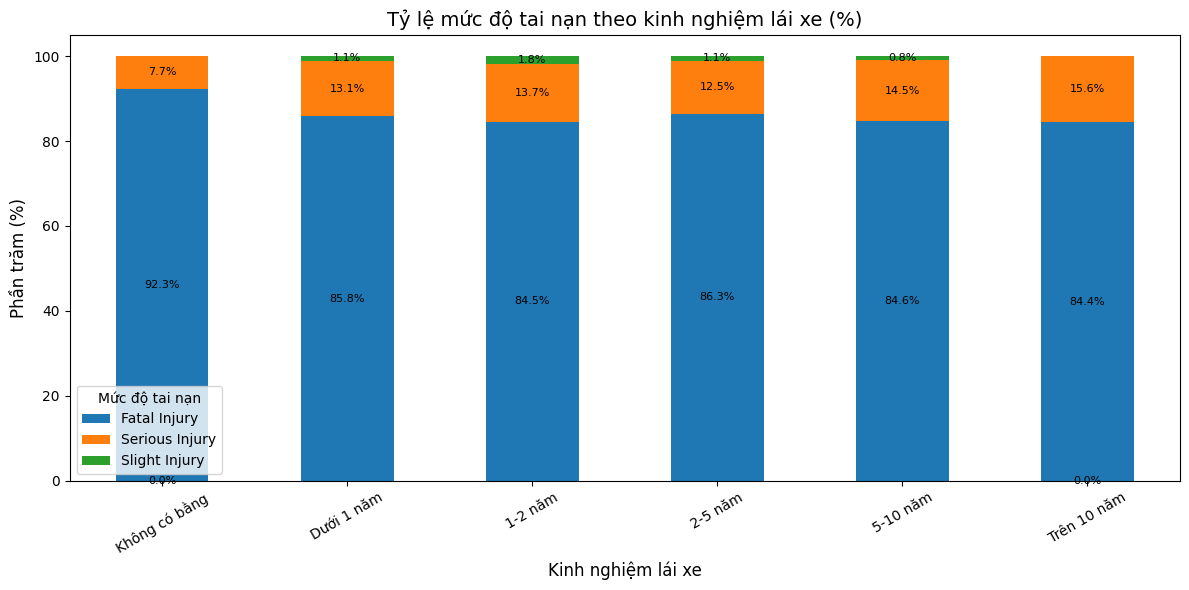

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Đổi mức độ tai nạn từ số sang chữ
severity_map = {
    0: 'Slight Injury',
    1: 'Serious Injury',
    2: 'Fatal Injury'
}

df['Severity_label'] = df['Accident_severity'].map(severity_map)

#  Map kinh nghiệm lái xe sang dạng năm (chỉnh lại đúng thứ tự nếu cần)
exp_map = {
    0: 'Dưới 1 năm',
    1: '1-2 năm',
    2: '2-5 năm',
    3: '5-10 năm',
    4: 'Trên 10 năm',
    5: 'Không có bằng'
}

df['Experience_label'] = df['Driving_experience'].map(exp_map)

# Tạo bảng tỷ lệ %
exp_severity = pd.crosstab(
    df['Experience_label'],
    df['Severity_label'],
    normalize='index'
) * 100

exp_severity = exp_severity.round(2)

# Sắp xếp lại theo thứ tự kinh nghiệm tăng dần
order = ['Không có bằng','Dưới 1 năm','1-2 năm','2-5 năm','5-10 năm','Trên 10 năm']
exp_severity = exp_severity.reindex(order)
# Vẽ biểu đồ
ax = exp_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Tỷ lệ mức độ tai nạn theo kinh nghiệm lái xe (%)", fontsize=14)
plt.xlabel("Kinh nghiệm lái xe", fontsize=12)
plt.ylabel("Phần trăm (%)", fontsize=12)

plt.xticks(rotation=30)
plt.legend(title="Mức độ tai nạn")
# Hiển thị % trên cột (đẹp hơn)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

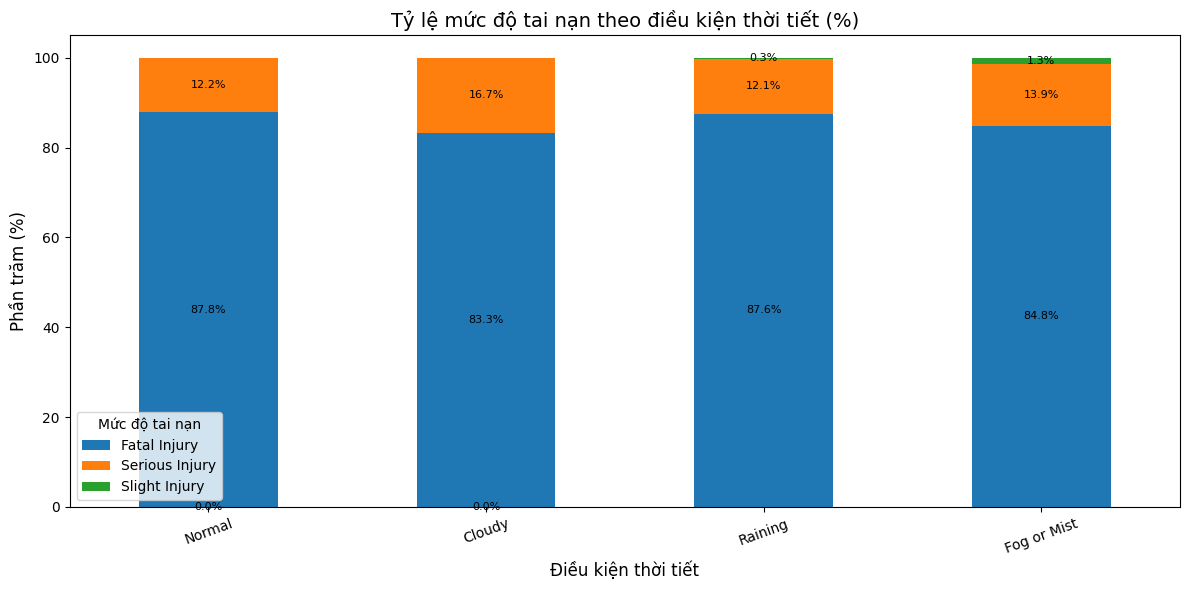

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1️⃣ ĐỔI NHÃN MỨC ĐỘ TAI NẠN
# =========================
severity_map = {
    0: 'Slight Injury',
    1: 'Serious Injury',
    2: 'Fatal Injury'
}

df['Severity_label'] = df['Accident_severity'].map(severity_map)


# =========================
# 2️⃣ ĐỔI NHÃN THỜI TIẾT
# (CHỈNH LẠI ĐÚNG THEO DATASET CỦA BẠN NẾU KHÁC)
# =========================
weather_map = {
    0: 'Cloudy',
    1: 'Fog or Mist',
    2: 'Normal',
    3: 'Raining'
}

df['Weather_label'] = df['Weather_conditions'].map(weather_map)


# =========================
# 3️⃣ TẠO BẢNG TỶ LỆ %
# =========================
weather_severity = pd.crosstab(
    df['Weather_label'],
    df['Severity_label'],
    normalize='index'
) * 100

weather_severity = weather_severity.round(2)


# =========================
# 4️⃣ SẮP XẾP THỨ TỰ THỜI TIẾT
# =========================
order = ['Normal', 'Cloudy', 'Raining', 'Fog or Mist']
weather_severity = weather_severity.reindex(order)


# =========================
# 5️⃣ VẼ BIỂU ĐỒ
# =========================
ax = weather_severity.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Tỷ lệ mức độ tai nạn theo điều kiện thời tiết (%)", fontsize=14)
plt.xlabel("Điều kiện thời tiết", fontsize=12)
plt.ylabel("Phần trăm (%)", fontsize=12)

plt.xticks(rotation=20)
plt.legend(title="Mức độ tai nạn")

# Hiển thị % trên cột (đẹp hơn)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

## Chương 3. Kết luận

### 3.1. Kết luận

### 3.2. Hướng phát triển

#Danh sách thành viên nhóm

---



|MSSV|Họ tên| Lớp | Công việc|
|----|------|------|---------|
|110123063| Thạch Chí Vĩnh  |DA23TTB| Chuẩn bị dữ liệu; Chuẩn bị báo cáo
|110123244| Nguyễn Quốc Anh |DA23TTB| Chuẩn bị dữ liệu; Chuẩn bị báo cáo
|110123069| Trần Nguyễn Hoàng Ân|DA23TTB| Chuẩn bị dữ liệu; Chuẩn bị báo cáo

###